In [4]:
import os
import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
from collections import Counter

print("All imports OK")
print("OpenCV:", cv2.__version__)

All imports OK
OpenCV: 4.13.0


In [5]:
# ── ONLY EDIT THESE ───────────────────────────────────────────────
DATASET_ROOT = "../datasets 2"              # ← folder name has a space
YAML_PATH    = "../datasets 2/sign.yaml"    # ← sign.yaml is directly inside datasets 2/
# ──────────────────────────────────────────────────────────────────

TRAIN_IMAGES = os.path.join(DATASET_ROOT, "train", "images")
TRAIN_LABELS = os.path.join(DATASET_ROOT, "train", "labels")
VALID_IMAGES = os.path.join(DATASET_ROOT, "valid", "images")
VALID_LABELS = os.path.join(DATASET_ROOT, "valid", "labels")

assert os.path.isfile(YAML_PATH),   f"❌ sign.yaml not found at: {YAML_PATH}"
assert os.path.isdir(TRAIN_IMAGES), f"❌ train/images not found"
assert os.path.isdir(TRAIN_LABELS), f"❌ train/labels not found"

with open(YAML_PATH, "r") as f:
    cfg = yaml.safe_load(f)

class_names = cfg["names"]
nc          = cfg["nc"]

print(f"✅ Dataset found")
print(f"   Number of classes : {nc}")
print(f"   Class names       : {class_names}")

✅ Dataset found
   Number of classes : 32
   Class names       : ['ain', 'al', 'aleff', 'bb', 'dal', 'dha', 'dhad', 'fa', 'gaaf', 'ghain', 'ha', 'haa', 'jeem', 'kaaf', 'khaa', 'la', 'laam', 'meem', 'nun', 'ra', 'saad', 'seen', 'sheen', 'ta', 'taa', 'thaa', 'thal', 'toot', 'waw', 'ya', 'yaa', 'zay']


In [6]:
# Each .txt label file has one line per object: "class_id cx cy w h"
# We read every label file and count occurrences of each class_id

label_files   = sorted([f for f in os.listdir(TRAIN_LABELS) if f.endswith(".txt")])
total_images  = len(os.listdir(TRAIN_IMAGES))
class_counts  = Counter()

for lf in label_files:
    with open(os.path.join(TRAIN_LABELS, lf)) as f:
        for line in f:
            line = line.strip()
            if line:
                cls_id = int(line.split()[0])
                class_counts[cls_id] += 1

total_annotations = sum(class_counts.values())

print(f"Total images in train   : {total_images:,}")
print(f"Total label files       : {len(label_files):,}")
print(f"Total annotations       : {total_annotations:,}")
print(f"Average per class       : {total_annotations // nc}")
print()

print(f"{'ID':>4}  {'Letter':>8}  {'Count':>6}")
print("-" * 25)
for cls_id in range(nc):
    name  = class_names[cls_id]
    count = class_counts.get(cls_id, 0)
    bar   = "█" * (count // 100)
    print(f"  {cls_id:>2}  {name:>8}  {count:>6}  {bar}")

Total images in train   : 9,955
Total label files       : 9,955
Total annotations       : 9,956
Average per class       : 311

  ID    Letter   Count
-------------------------
   0       ain     315  ███
   1        al     315  ███
   2     aleff     313  ███
   3        bb     312  ███
   4       dal     291  ██
   5       dha     315  ███
   6      dhad     309  ███
   7        fa     315  ███
   8      gaaf     310  ███
   9     ghain     315  ███
  10        ha     315  ███
  11       haa     314  ███
  12      jeem     313  ███
  13      kaaf     311  ███
  14      khaa     315  ███
  15        la     315  ███
  16      laam     308  ███
  17      meem     315  ███
  18       nun     298  ██
  19        ra     304  ███
  20      saad     315  ███
  21      seen     315  ███
  22     sheen     315  ███
  23        ta     315  ███
  24       taa     309  ███
  25      thaa     314  ███
  26      thal     315  ███
  27      toot     315  ███
  28       waw     291  ██
  29        ya 

### Bar chart of class distribution ###

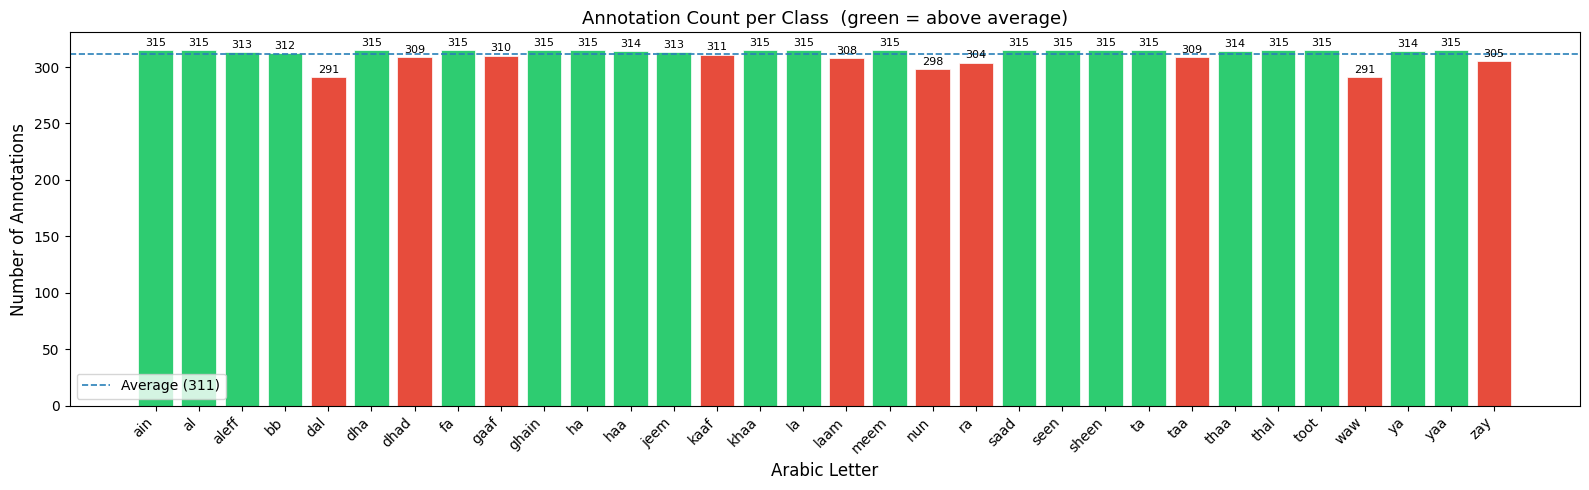

✅ Saved to outputs/class_distribution.png


In [7]:
ids    = list(range(nc))
counts = [class_counts.get(i, 0) for i in ids]
names  = [class_names[i] for i in ids]
avg    = sum(counts) / len(counts)

colors = ["#2ecc71" if c >= avg else "#e74c3c" for c in counts]

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(names, counts, color=colors, edgecolor="white", linewidth=0.5)
ax.axhline(avg, color="#2980b9", linestyle="--", linewidth=1.2,
           label=f"Average ({avg:.0f})")

ax.set_xlabel("Arabic Letter", fontsize=12)
ax.set_ylabel("Number of Annotations", fontsize=12)
ax.set_title("Annotation Count per Class  (green = above average)", fontsize=13)
ax.legend()
plt.xticks(rotation=45, ha="right")

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 2,
            str(count), ha="center", va="bottom", fontsize=8)

plt.tight_layout()
os.makedirs("../outputs", exist_ok=True)
plt.savefig("../outputs/class_distribution.png", dpi=150)
plt.show()
print("✅ Saved to outputs/class_distribution.png")

### Display sample images WITH bounding boxes drawn ###

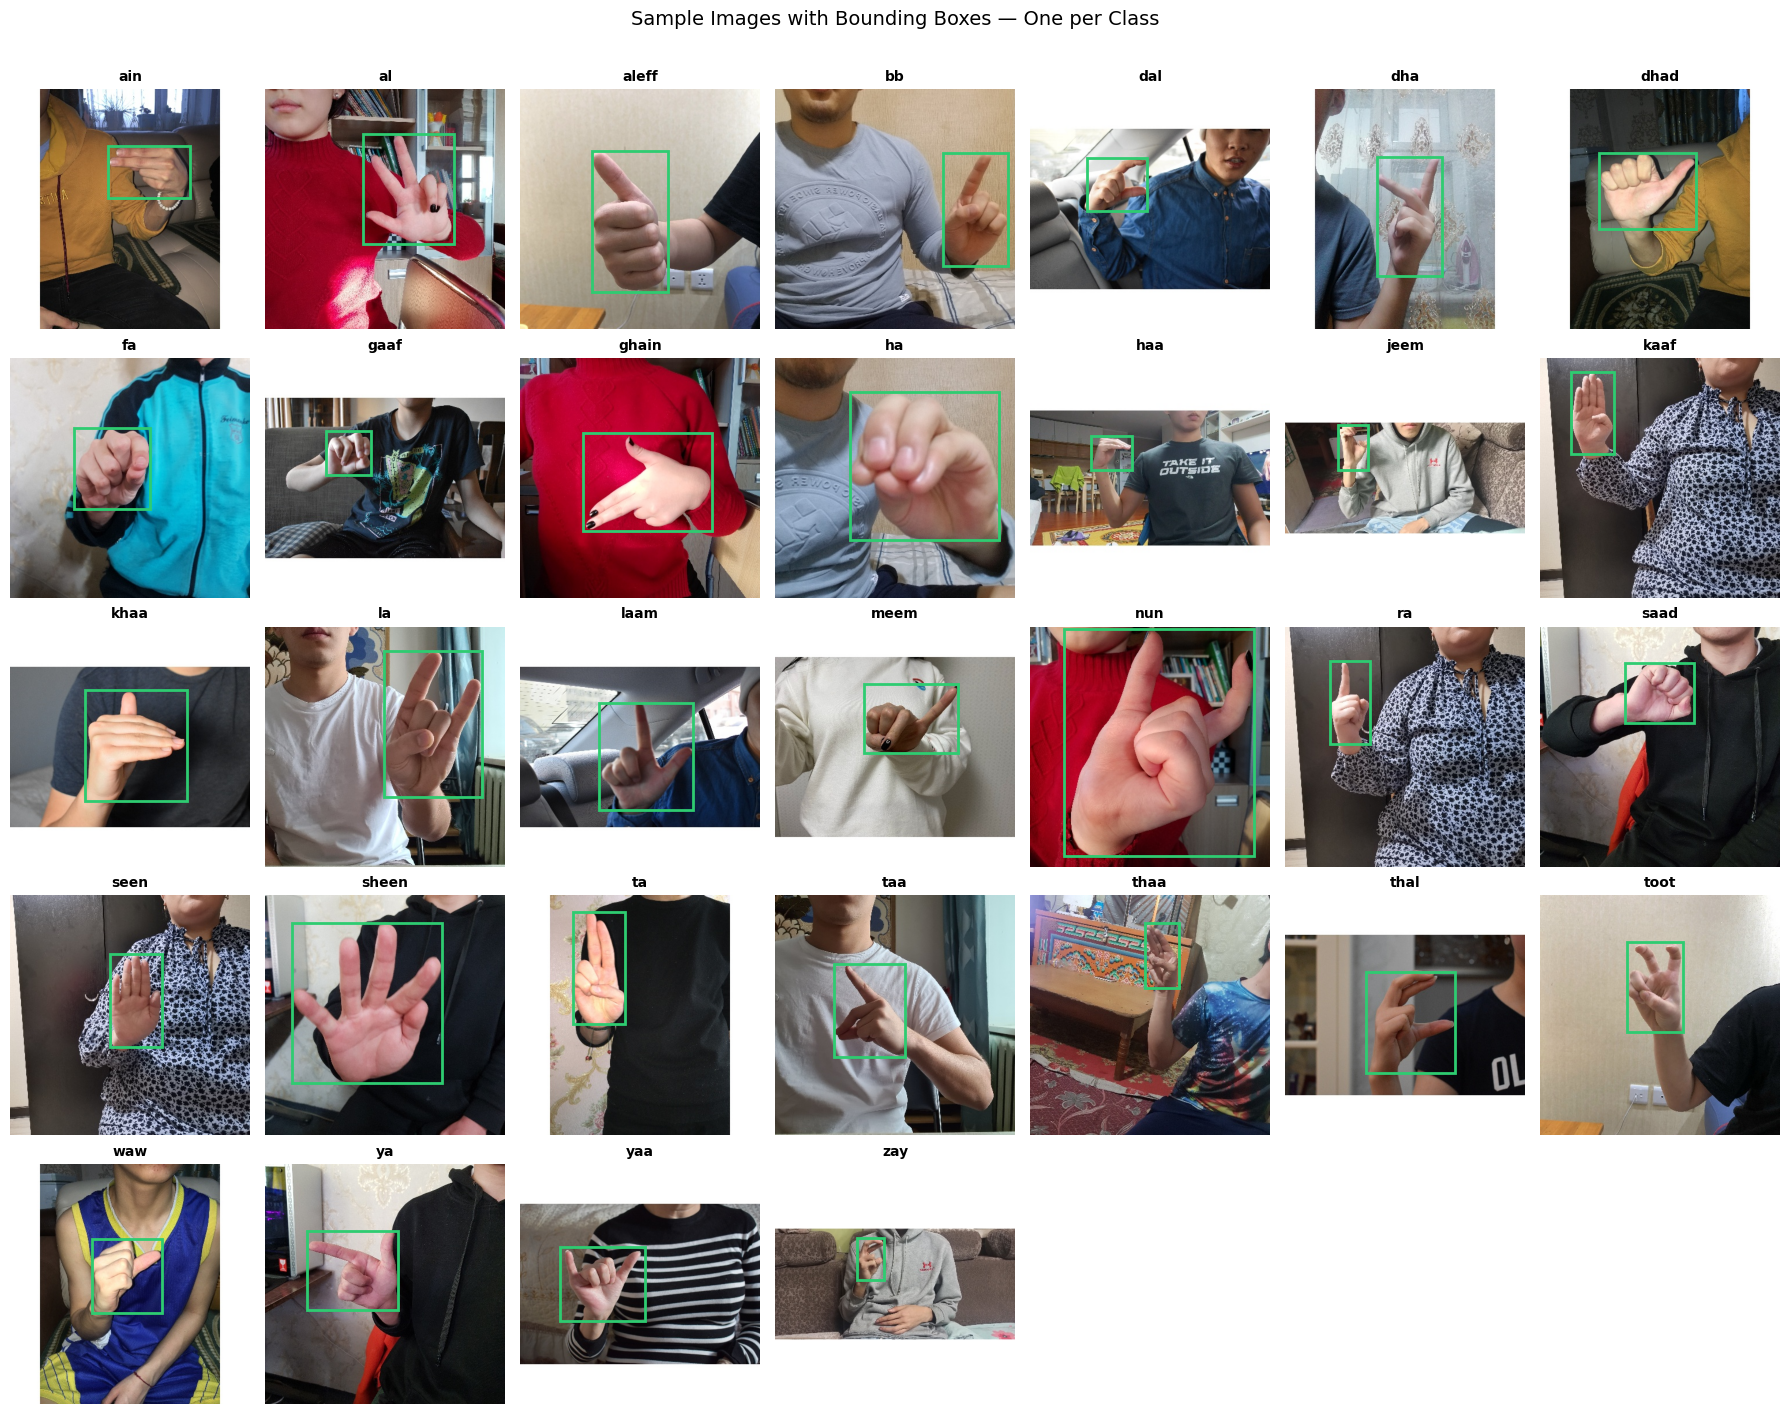

✅ Saved to outputs/sample_images.png


In [8]:
import math

def yolo_to_pixel(cx, cy, w, h, img_w, img_h):
    x1 = int((cx - w / 2) * img_w)
    y1 = int((cy - h / 2) * img_h)
    x2 = int((cx + w / 2) * img_w)
    y2 = int((cy + h / 2) * img_h)
    return max(0, x1), max(0, y1), min(img_w, x2), min(img_h, y2)

cols = 7
rows = math.ceil(nc / cols)
fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 2.8))
axes = axes.flatten()

# Build lookup: class_id -> list of label files containing it
class_to_files = {i: [] for i in range(nc)}
for lf in label_files:
    with open(os.path.join(TRAIN_LABELS, lf)) as f:
        ids_in_file = set()
        for line in f:
            line = line.strip()
            if line:
                ids_in_file.add(int(line.split()[0]))
    for cid in ids_in_file:
        if cid in class_to_files:
            class_to_files[cid].append(lf)

IMG_EXTS = [".jpg", ".jpeg", ".png"]

for i in range(len(axes)):
    ax = axes[i]
    
    # Hide extra axes beyond nc
    if i >= nc:
        ax.axis("off")
        continue

    if not class_to_files[i]:
        ax.axis("off")
        ax.set_title(class_names[i], fontsize=10)
        continue

    lf       = random.choice(class_to_files[i])
    stem     = os.path.splitext(lf)[0]
    img_path = None

    for ext in IMG_EXTS:
        candidate = os.path.join(TRAIN_IMAGES, stem + ext)
        if os.path.exists(candidate):
            img_path = candidate
            break

    if img_path is None:
        ax.axis("off")
        continue

    img      = cv2.imread(img_path)
    img_rgb  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_h, img_w = img.shape[:2]

    ax.imshow(img_rgb)

    with open(os.path.join(TRAIN_LABELS, lf)) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts  = line.split()
            cls_id = int(parts[0])
            if cls_id != i:
                continue
            cx, cy, w, h = map(float, parts[1:5])
            x1, y1, x2, y2 = yolo_to_pixel(cx, cy, w, h, img_w, img_h)
            rect = patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=2, edgecolor="#2ecc71", facecolor="none"
            )
            ax.add_patch(rect)

    ax.set_title(class_names[i], fontsize=10, fontweight="bold")
    ax.axis("off")

plt.suptitle("Sample Images with Bounding Boxes — One per Class", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../outputs/sample_images.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved to outputs/sample_images.png")

In [9]:
img_files  = os.listdir(TRAIN_IMAGES)
sizes      = Counter()

for fname in img_files[:200]:   # check first 200
    img = cv2.imread(os.path.join(TRAIN_IMAGES, fname))
    if img is not None:
        sizes[img.shape[:2]] += 1

print("Image sizes found:")
for (h, w), count in sizes.most_common():
    print(f"  {w} × {h} px  →  {count} images checked")

Image sizes found:
  416 × 416 px  →  200 images checked


In [10]:
print("=" * 48)
print("        DATASET SUMMARY")
print("=" * 48)
print(f"  Format              : YOLO detection")
print(f"  Total images        : {total_images:,}")
print(f"  Total annotations   : {total_annotations:,}")
print(f"  Number of classes   : {nc}")
print(f"  Avg annotations/cls : {total_annotations // nc:,}")
most_common  = class_names[class_counts.most_common(1)[0][0]]
least_common = class_names[class_counts.most_common()[-1][0]]
print(f"  Most annotated      : {most_common}")
print(f"  Least annotated     : {least_common}")
print("=" * 48)
print("\nNext → Notebook 02: Extract Landmarks")

        DATASET SUMMARY
  Format              : YOLO detection
  Total images        : 9,955
  Total annotations   : 9,956
  Number of classes   : 32
  Avg annotations/cls : 311
  Most annotated      : ain
  Least annotated     : waw

Next → Notebook 02: Extract Landmarks
